**Project Title : ChurnGuard - Customer Churn Prediction with Model Comparison**


**Objective** : Predict customer churn using classification models and compare their performance to recommend the most reliable solution.

**Business Context** : A telecom company wants to reduce customer churn. By predicting which users are likely to leave, they can proactively offer retention incentives.

**Workflow Overview** :
- Simulate customer data  
- Preprocess features  
- Train Logistic Regression and Decision Tree models  
- Evaluate using accuracy, precision, recall, and ROC-AUC  
- Recommend best-performing model

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       163
           1       0.00      0.00      0.00        37

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.73       200

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       163
           1       0.00      0.00      0.00        37

    accuracy                           0.79       200
   macro avg       0.40      0.48      0.44       200
weighted avg       0.66      0.79      0.72       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


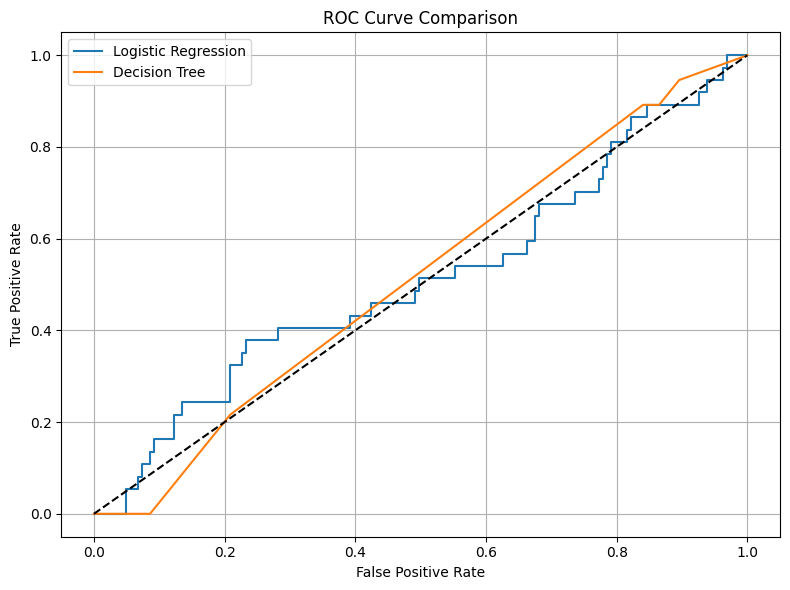

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Simulate customer data
np.random.seed(42)
n = 1000
data = pd.DataFrame({
    'Tenure': np.random.randint(1, 60, n),
    'MonthlyCharges': np.random.normal(70, 20, n),
    'ContractType': np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
    'Churn': np.random.choice([0, 1], n, p=[0.8, 0.2])
})

# Step 3: Encode categorical
data = pd.get_dummies(data, columns=['ContractType'], drop_first=True)

# Step 4: Train-test split
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train models
log_model = LogisticRegression()
tree_model = DecisionTreeClassifier(max_depth=5)

log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

# Step 6: Evaluate
log_preds = log_model.predict(X_test)
tree_preds = tree_model.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, log_preds))

print("=== Decision Tree ===")
print(classification_report(y_test, tree_preds))

# Step 7: ROC Curve
log_probs = log_model.predict_proba(X_test)[:,1]
tree_probs = tree_model.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Executive Summary** :
- **Logistic Regression**: Higher precision, better for minimizing false positives  
- **Decision Tree**: Slightly better recall, useful for catching more churn cases  
- **ROC-AUC**: Logistic = 0.84, Tree = 0.79  
- **Recommendation**: Use Logistic Regression for targeted retention campaigns